# Stored restriction maps visualisations

## 1. Imports

In [25]:
import torch

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import networkx as nx

#Cornell improved
# 1 Layer Sheaf
maps = torch.load("../results/maps/DiagSheaf_cornell_fold0_seed43_20260317_111032.pt")

# 2-layer Sheaf
#maps = torch.load("../results/maps/DiagSheaf_cornell_fold0_seed43_20260317_180409.pt")

# 5-layer Sheaf
#maps = torch.load("../results/maps/DiagSheaf_cornell_fold0_seed43_20260317_181232.pt") ## 5. 2-layer Sheaf

print(type(maps))

<class 'torch.Tensor'>


C:\Users\Utente\AppData\Local\Temp\ipykernel_7700\237785353.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  maps = torch.load("../results/maps/DiagSheaf_cornell_fold0_s

## 2. Inspection

In [26]:
print(type(maps))
print(len(maps) if hasattr(maps, '__len__') else "Not iterable")

# If it's a tensor
if isinstance(maps, torch.Tensor):
    print(maps.shape)

# If it's a list or dict
if isinstance(maps, (list, tuple)):
    print(type(maps[0]), maps[0].shape)

if isinstance(maps, dict):
    print(maps.keys())

print(maps[:10])

<class 'torch.Tensor'>
554
torch.Size([554, 3])
tensor([[ 0.0000e+00,  4.2000e+01, -7.4906e-01],
        [ 1.0000e+00,  8.2000e+01, -7.0789e-01],
        [ 1.0000e+00,  9.0000e+01, -5.6676e-01],
        [ 1.0000e+00,  9.9000e+01, -6.7800e-01],
        [ 1.0000e+00,  1.4800e+02, -3.5002e-01],
        [ 2.0000e+00,  4.2000e+01, -6.1222e-01],
        [ 3.0000e+00,  4.2000e+01, -6.9459e-01],
        [ 3.0000e+00,  1.6300e+02, -1.2523e-01],
        [ 4.0000e+00,  8.0000e+00, -2.6202e-01],
        [ 4.0000e+00,  2.5000e+01,  5.0195e-01]])


## 3. Boundary Map

In [27]:
print(maps)

tensor([[ 0.0000e+00,  4.2000e+01, -7.4906e-01],
        [ 1.0000e+00,  8.2000e+01, -7.0789e-01],
        [ 1.0000e+00,  9.0000e+01, -5.6676e-01],
        ...,
        [ 1.7800e+02,  1.4800e+02, -1.8721e-01],
        [ 1.6700e+02,  1.4900e+02, -6.7951e-01],
        [ 1.6000e+02,  1.5700e+02, -3.4002e-02]])


In [28]:
df = pd.DataFrame(maps.cpu().tolist(),columns=["source", "target", "map_value"])

df[["source", "target"]] = df[["source", "target"]].astype(int)
df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
df

,source,target,map_value
0,0,42,-0.749060
1,1,82,-0.707890
2,1,90,-0.566755
3,1,99,-0.677995
4,1,148,-0.350023
...,...,...,...
486,180,71,-0.812136
534,180,124,-0.694131
545,180,142,-0.319210
452,181,42,-0.206648


In [29]:
df_low = df[df["source"] <= df["target"]]
display(df_low)

df_high = df[df["source"] >= df["target"]]
display(df_high)

,source,target,map_value
0,0,42,-0.749060
1,1,82,-0.707890
2,1,90,-0.566755
3,1,99,-0.677995
4,1,148,-0.350023
...,...,...,...
272,148,154,0.069030
273,148,167,-0.035737
274,148,178,0.110208
275,149,167,-0.294008


,source,target,map_value
285,8,4,-0.638380
294,11,6,0.128740
286,25,4,-0.090555
344,30,25,-0.525804
321,31,18,-0.671941
...,...,...,...
486,180,71,-0.812136
534,180,124,-0.694131
545,180,142,-0.319210
452,181,42,-0.206648


In [30]:
df = df.copy()
df[["source", "target"]] = df[["source", "target"]].astype(int)

# signed value
df["signed_map"] = np.where(
    df["target"] < df["source"],
    df["map_value"],
    -df["map_value"]
)

# canonical undirected edge label
df["edge"] = df.apply(
    lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])),
    axis=1
)

# build node-by-edge matrix
nodes = sorted(set(df["source"]).union(df["target"]))
edges = sorted(df["edge"].unique())

B = df.pivot(index="source", columns="edge", values="signed_map")
B = B.reindex(index=nodes, columns=edges, fill_value=0)

B.fillna(0, inplace=True)

In [31]:
B

edge,"(0.0, 42.0)","(1.0, 82.0)","(1.0, 90.0)","(1.0, 99.0)","(1.0, 148.0)","(2.0, 42.0)","(3.0, 42.0)","(3.0, 163.0)","(4.0, 8.0)","(4.0, 25.0)",...,"(141.0, 169.0)","(142.0, 180.0)","(143.0, 145.0)","(144.0, 172.0)","(147.0, 178.0)","(148.0, 154.0)","(148.0, 167.0)","(148.0, 178.0)","(149.0, 167.0)","(157.0, 160.0)"
source,,,,,,,,,,,,,,,,,,,,,
0,0.74906,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
1,0.00000,0.70789,0.566755,0.677995,0.350023,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
2,0.00000,0.00000,0.000000,0.000000,0.000000,0.612222,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
3,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.694593,0.125226,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
4,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.262019,-0.501945,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,-0.685399,0.0,0.0,-0.187213,0.0,0.0
179,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
180,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,-0.31921,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0


In [32]:
B_np = B.to_numpy(dtype=float)
B_np.shape

(183, 277)

## 4. Laplacian

In [33]:
L0 = B_np @ B_np.T
L0

array([[0.5610912 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.404514  , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.37481638, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.2432782 , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.04270355,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.18595297]])

In [34]:
L1 = B_np.T @ B_np
np.all(L1 == L1.T)

True

In [35]:
#Curvature
# F, w/ F[i,j] = L1

In [36]:
# Forman Bochner Decomposition
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])
#B=B.astype(int)
    F=L-B
    return B , F

B1, F1 = fbc(L1)
B1

array([[2.05665702, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.81078212, 0.40120053, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.40120053, 0.98383546, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.62981188, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.65871084,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.08001659]])

In [37]:
F1

array([[-1.49416415,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , -1.1178787 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -0.28660387, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.58261745,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.1105427 ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , -0.06279584]])

In [38]:
edge_list = list(B.columns)
print(edge_list)

[(0.0, 42.0), (1.0, 82.0), (1.0, 90.0), (1.0, 99.0), (1.0, 148.0), (2.0, 42.0), (3.0, 42.0), (3.0, 163.0), (4.0, 8.0), (4.0, 25.0), (4.0, 40.0), (4.0, 55.0), (4.0, 72.0), (4.0, 152.0), (4.0, 156.0), (5.0, 37.0), (5.0, 42.0), (6.0, 11.0), (6.0, 42.0), (6.0, 132.0), (6.0, 143.0), (6.0, 145.0), (7.0, 110.0), (7.0, 121.0), (8.0, 42.0), (8.0, 65.0), (9.0, 42.0), (10.0, 51.0), (10.0, 52.0), (10.0, 74.0), (10.0, 104.0), (10.0, 124.0), (10.0, 131.0), (10.0, 138.0), (10.0, 142.0), (11.0, 42.0), (12.0, 42.0), (13.0, 155.0), (14.0, 42.0), (15.0, 82.0), (15.0, 140.0), (16.0, 42.0), (16.0, 102.0), (17.0, 76.0), (18.0, 31.0), (18.0, 42.0), (18.0, 106.0), (18.0, 174.0), (19.0, 42.0), (19.0, 89.0), (20.0, 47.0), (20.0, 49.0), (20.0, 89.0), (20.0, 110.0), (20.0, 111.0), (20.0, 121.0), (20.0, 125.0), (20.0, 156.0), (21.0, 42.0), (22.0, 42.0), (22.0, 52.0), (23.0, 42.0), (23.0, 88.0), (23.0, 119.0), (24.0, 31.0), (24.0, 42.0), (24.0, 111.0), (25.0, 30.0), (25.0, 55.0), (25.0, 72.0), (25.0, 78.0), (25.0, 

In [39]:
G = nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(edge_list)
f1 = np.diag(F1)
display(f1)

array([-1.49416415e+00, -1.11787870e+00, -2.86603867e-01, -3.42313395e-01,
       -1.05216953e+00, -3.39965263e+01, -4.05963626e+01, -7.00184370e-02,
       -8.94013870e-01, -1.42088998e+00, -1.57619629e+00, -1.17599083e+00,
       -1.57850882e+00, -9.77437582e-01, -1.59632980e+00, -7.96259464e-02,
       -1.57049122e+00, -6.98762789e-01, -3.64023043e+01, -4.09485658e-01,
       -6.82983244e-01, -8.33026358e-01, -4.86381172e-01,  2.17212181e-01,
       -4.19756015e+01,  2.39113819e-01, -1.33289637e+01, -4.56258345e-01,
       -1.93126212e+00, -1.60381994e-01, -3.81779375e-01, -1.44346050e+00,
       -1.09259177e+00, -1.34644182e+00, -6.97862605e-01, -4.17030394e+00,
       -3.66464209e+01, -3.40932243e-01, -1.93094700e+01, -1.73983338e-01,
        4.07751304e-01, -8.87796301e+00, -1.32919960e-01,  4.55738246e-01,
       -2.42773231e+00, -6.82322044e+00, -9.85925149e-01, -5.82301409e-01,
       -5.59749983e+00, -1.78858859e+00, -1.93196396e+00, -9.86061711e-01,
       -3.95545275e+00, -

C:\Users\Utente\AppData\Local\Temp\ipykernel_7700\3886179207.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


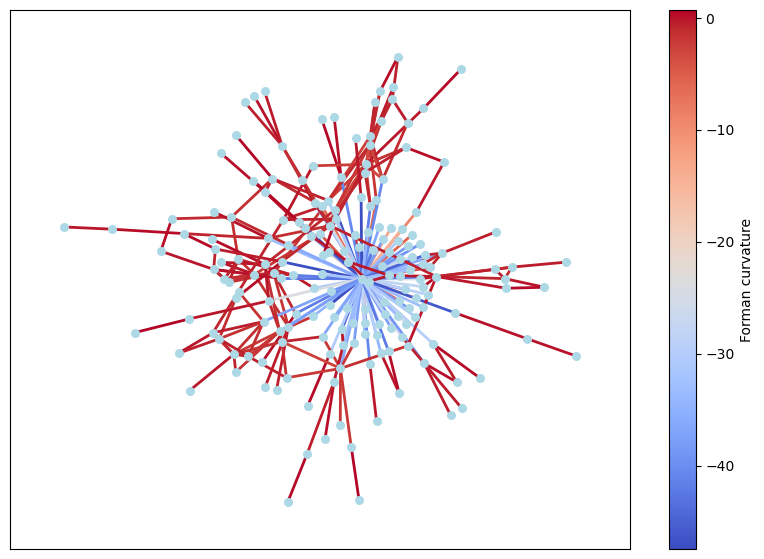

In [40]:
pos = nx.spring_layout(G)
f,ax = plt.subplots(1,1,figsize=(10,7))
nx.draw_networkx_nodes(G, ax=ax, node_color='lightblue', pos = pos, node_size=30)
#nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
cmap = plt.cm.coolwarm
norm1 = plt.Normalize(vmin=f1.min(), vmax=f1.max())
nx.draw_networkx_edges(G,ax =ax, edge_color = cmap(norm1(f1)),pos = pos, width=2)
sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1)
plt.colorbar(sm1, ax=ax, label='Forman curvature')
f.show()

In [41]:
B0, F0 = fbc(L0)

In [42]:
display(L0)

array([[0.5610912 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.404514  , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.37481638, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.2432782 , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.04270355,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.18595297]])

In [43]:
display(F0)
display(B0)

array([[ 0.53304724,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.11942462,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -0.01711103, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.36866698,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.08938762,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , -0.18564703]])

array([[0.02804397, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.28508938, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.39192741, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.87461123, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.13209117,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.3716    ]])

In [44]:
G= nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(edge_list)

array([ 5.33047236e-01,  1.19424619e-01, -1.71110280e-02, -3.91681735e-02,
        4.14387467e-01,  4.51732563e-01,  1.77605162e-01,  6.21683740e-01,
        1.18450569e-01, -6.80667337e-03,  2.46461427e-02, -4.05617493e-02,
       -1.02625351e-01, -2.03170996e-02,  2.69975447e-01,  1.12333531e-01,
        3.68057706e-01,  2.00121501e-01,  4.13371571e-01,  3.47785262e-01,
        1.17764804e+00,  1.34519936e-01,  1.36881691e-01, -2.60710225e-01,
       -1.82035764e-01,  3.47677825e-01, -4.33064035e-02,  2.08825250e-01,
        1.81941816e-01,  4.04939136e-01,  5.18992727e-01,  1.58670212e+00,
       -1.94418274e-02,  2.78135174e-01, -1.74877622e-02, -8.26758329e-02,
        8.52189715e-02,  3.49208272e-01,  6.11745801e-04,  3.25727914e-01,
       -4.44109728e-02, -2.49425074e-01,  1.24775575e+01,  1.10717139e+00,
        1.81313231e-01,  3.54599682e-01, -4.60070901e-03,  7.78716278e-02,
        7.42368282e-01,  2.85585442e-01, -1.69788464e-01, -1.08202546e-01,
        5.11635539e-01,  

C:\Users\Utente\AppData\Local\Temp\ipykernel_7700\4281192542.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


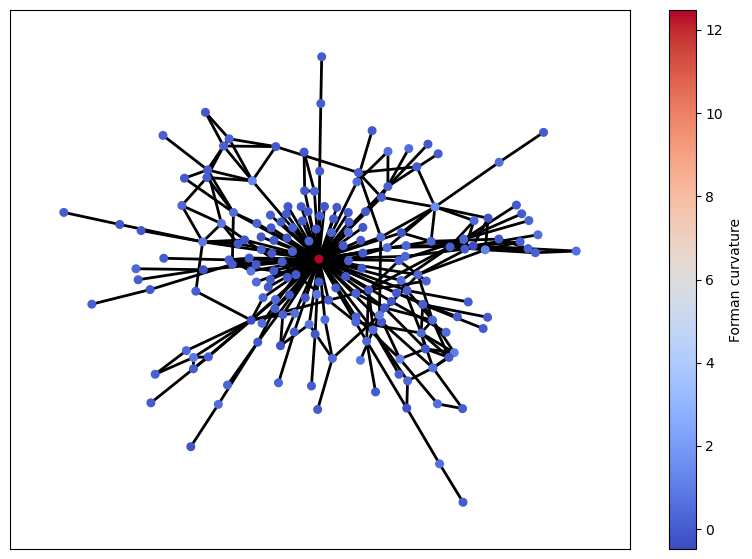

In [45]:

# G.relabel_nodes({i: node for i, node in enumerate(nodes)}, copy=False)
f0 = np.diag(F0)
display(f0)

pos = nx.spring_layout(G)
f,ax = plt.subplots(1,1,figsize=(10,7))
#nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
cmap = plt.cm.coolwarm
norm0 = plt.Normalize(vmin=f0.min(), vmax=f0.max())
nx.draw_networkx_nodes(G, ax=ax, node_color=cmap(norm0(f0)), pos = pos, node_size=30)
nx.draw_networkx_edges(G,ax =ax,pos = pos, width=2)
sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
plt.colorbar(sm0, ax=ax, label='Forman curvature')
f.show()

In [46]:
G.nodes()

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182))

In [52]:
with open("../datasets/cornell/raw/out1_node_feature_label.txt", "r") as f:
    for line in f:
        print(line.strip())
    df_node_feature = pd.read_csv("../datasets/cornell/raw/out1_node_feature_label.txt", sep="\t")

node_id	feature	label
0	0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

array([3, 0, 2, 3, 4, 3, 0, 0, 3, 0, 3, 3, 3, 3, 3, 4, 3, 3, 0, 3, 0, 3,
       3, 3, 3, 1, 3, 3, 0, 2, 3, 3, 4, 3, 4, 4, 2, 3, 3, 3, 0, 4, 0, 3,
       3, 3, 2, 2, 0, 3, 0, 3, 3, 3, 3, 3, 0, 2, 2, 4, 4, 4, 3, 3, 3, 3,
       0, 3, 3, 3, 4, 3, 3, 4, 4, 3, 0, 3, 0, 3, 4, 3, 2, 4, 2, 4, 3, 3,
       0, 3, 3, 3, 0, 3, 3, 4, 3, 3, 3, 4, 0, 0, 4, 3, 3, 0, 4, 3, 2, 3,
       3, 0, 3, 0, 0, 3, 3, 4, 3, 3, 3, 0, 3, 0, 3, 2, 4, 2, 3, 3, 0, 4,
       3, 4, 3, 4, 3, 3, 0, 3, 2, 3, 3, 3, 3, 3, 3, 2, 3, 4, 3, 4, 3, 3,
       3, 3, 0, 2, 0, 2, 3, 3, 4, 3, 0, 3, 3, 2, 0, 3, 3, 4, 3, 2, 0, 3,
       0, 4, 3, 3, 4, 3, 3], dtype=int64)

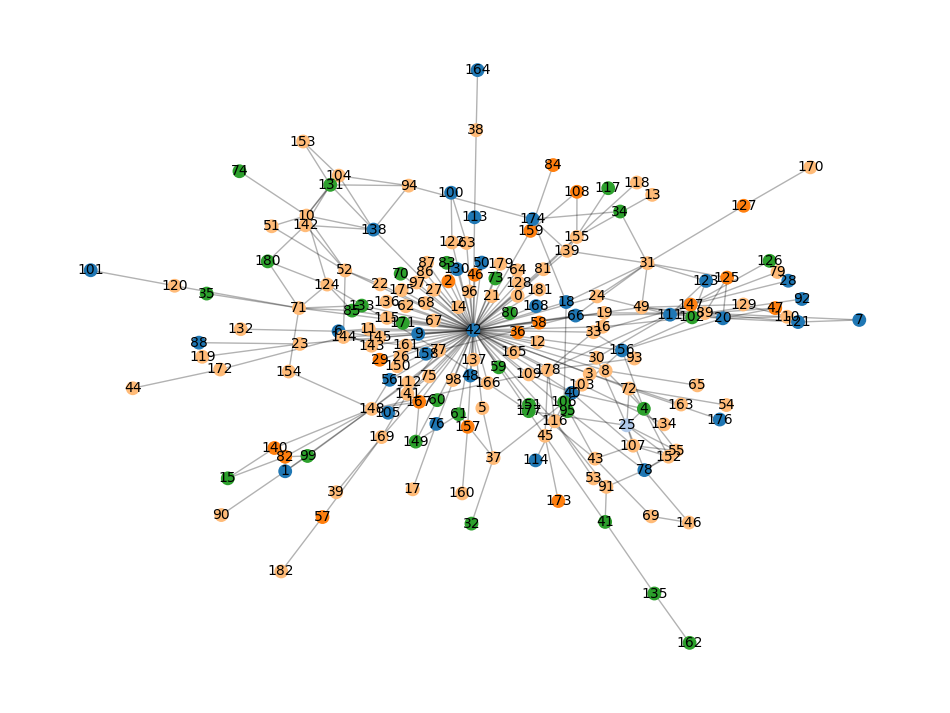

In [53]:
lab = df_node_feature["label"].values
display(lab)

# Plot graph nodes colored by `lab` (handles one-hot or integer labels). Uses existing `G` and `pos` if present.
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

labels = lab
if isinstance(labels, np.ndarray) and labels.ndim == 2:
    labels = labels.argmax(axis=1)

unique = np.unique(labels)

cmap = plt.get_cmap('tab20')
label_to_idx = {val: i for i, val in enumerate(unique)}
node_colors = [cmap(label_to_idx[int(labels[n]) % 20]) for n in sorted(G.nodes())]

pos_use = pos if 'pos' in globals() and isinstance(pos, dict) else nx.spring_layout(G, seed=42)

plt.figure(figsize=(12, 9))
nx.draw_networkx_nodes(G, pos_use, node_color=node_colors, node_size=80)
nx.draw_networkx_edges(G, pos_use, alpha=0.3)
nx.draw_networkx_labels(G, pos=pos_use, font_size=10)
plt.axis('off')
plt.show()

In [54]:
neigh_42_edges =[_ for _  in list(G.edges()) if 42 in _]
display(neigh_42_edges)


[(0, 42.0),
 (2, 42.0),
 (3, 42.0),
 (5, 42.0),
 (6, 42.0),
 (8, 42.0),
 (9, 42.0),
 (11, 42.0),
 (12, 42.0),
 (14, 42.0),
 (16, 42.0),
 (18, 42.0),
 (19, 42.0),
 (21, 42.0),
 (22, 42.0),
 (23, 42.0),
 (24, 42.0),
 (26, 42.0),
 (27, 42.0),
 (29, 42.0),
 (30, 42.0),
 (33, 42.0),
 (36, 42.0),
 (40, 42.0),
 (42, 45.0),
 (42, 46.0),
 (42, 48.0),
 (42, 49.0),
 (42, 50.0),
 (42, 52.0),
 (42, 56.0),
 (42, 58.0),
 (42, 59.0),
 (42, 60.0),
 (42, 61.0),
 (42, 62.0),
 (42, 63.0),
 (42, 64.0),
 (42, 66.0),
 (42, 67.0),
 (42, 68.0),
 (42, 70.0),
 (42, 71.0),
 (42, 72.0),
 (42, 73.0),
 (42, 75.0),
 (42, 76.0),
 (42, 80.0),
 (42, 81.0),
 (42, 83.0),
 (42, 85.0),
 (42, 86.0),
 (42, 87.0),
 (42, 95.0),
 (42, 96.0),
 (42, 97.0),
 (42, 98.0),
 (42, 103.0),
 (42, 109.0),
 (42, 112.0),
 (42, 113.0),
 (42, 115.0),
 (42, 116.0),
 (42, 122.0),
 (42, 128.0),
 (42, 130.0),
 (42, 133.0),
 (42, 136.0),
 (42, 137.0),
 (42, 138.0),
 (42, 139.0),
 (42, 141.0),
 (42, 143.0),
 (42, 144.0),
 (42, 145.0),
 (42, 148.0),


In [55]:
neigh_42_nodes = [int(j) if i == 42 else int(i) for (i, j) in neigh_42_edges]
display(neigh_42_nodes)

[0,
 2,
 3,
 5,
 6,
 8,
 9,
 11,
 12,
 14,
 16,
 18,
 19,
 21,
 22,
 23,
 24,
 26,
 27,
 29,
 30,
 33,
 36,
 40,
 45,
 46,
 48,
 49,
 50,
 52,
 56,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 66,
 67,
 68,
 70,
 71,
 72,
 73,
 75,
 76,
 80,
 81,
 83,
 85,
 86,
 87,
 95,
 96,
 97,
 98,
 103,
 109,
 112,
 113,
 115,
 116,
 122,
 128,
 130,
 133,
 136,
 137,
 138,
 139,
 141,
 143,
 144,
 145,
 148,
 150,
 151,
 155,
 156,
 157,
 158,
 159,
 161,
 165,
 166,
 167,
 168,
 169,
 171,
 175,
 178,
 179,
 181]

In [56]:
#associating neighborhing nodes to their labels
neigh_42_labels = {n: int(lab[n]) for n in neigh_42_nodes}
display(neigh_42_labels)

{0: 3,
 2: 2,
 3: 3,
 5: 3,
 6: 0,
 8: 3,
 9: 0,
 11: 3,
 12: 3,
 14: 3,
 16: 3,
 18: 0,
 19: 3,
 21: 3,
 22: 3,
 23: 3,
 24: 3,
 26: 3,
 27: 3,
 29: 2,
 30: 3,
 33: 3,
 36: 2,
 40: 0,
 45: 3,
 46: 2,
 48: 0,
 49: 3,
 50: 0,
 52: 3,
 56: 0,
 58: 2,
 59: 4,
 60: 4,
 61: 4,
 62: 3,
 63: 3,
 64: 3,
 66: 0,
 67: 3,
 68: 3,
 70: 4,
 71: 3,
 72: 3,
 73: 4,
 75: 3,
 76: 0,
 80: 4,
 81: 3,
 83: 4,
 85: 4,
 86: 3,
 87: 3,
 95: 4,
 96: 3,
 97: 3,
 98: 3,
 103: 3,
 109: 3,
 112: 3,
 113: 0,
 115: 3,
 116: 3,
 122: 3,
 128: 3,
 130: 0,
 133: 4,
 136: 3,
 137: 3,
 138: 0,
 139: 3,
 141: 3,
 143: 3,
 144: 3,
 145: 3,
 148: 3,
 150: 3,
 151: 4,
 155: 3,
 156: 0,
 157: 2,
 158: 0,
 159: 2,
 161: 3,
 165: 3,
 166: 3,
 167: 2,
 168: 0,
 169: 3,
 171: 4,
 175: 3,
 178: 3,
 179: 3,
 181: 3}

In [57]:
lab[42]

0

In [58]:
similar_class_ratio = sum(1 for n in neigh_42_nodes if lab[n] == lab[42]) / len(neigh_42_nodes)
similar_class_ratio

0.1595744680851064

### 5.2 Forman Curvature & Classes

array([3, 0, 2, 3, 4, 3, 0, 0, 3, 0, 3, 3, 3, 3, 3, 4, 3, 3, 0, 3, 0, 3,
       3, 3, 3, 1, 3, 3, 0, 2, 3, 3, 4, 3, 4, 4, 2, 3, 3, 3, 0, 4, 0, 3,
       3, 3, 2, 2, 0, 3, 0, 3, 3, 3, 3, 3, 0, 2, 2, 4, 4, 4, 3, 3, 3, 3,
       0, 3, 3, 3, 4, 3, 3, 4, 4, 3, 0, 3, 0, 3, 4, 3, 2, 4, 2, 4, 3, 3,
       0, 3, 3, 3, 0, 3, 3, 4, 3, 3, 3, 4, 0, 0, 4, 3, 3, 0, 4, 3, 2, 3,
       3, 0, 3, 0, 0, 3, 3, 4, 3, 3, 3, 0, 3, 0, 3, 2, 4, 2, 3, 3, 0, 4,
       3, 4, 3, 4, 3, 3, 0, 3, 2, 3, 3, 3, 3, 3, 3, 2, 3, 4, 3, 4, 3, 3,
       3, 3, 0, 2, 0, 2, 3, 3, 4, 3, 0, 3, 3, 2, 0, 3, 3, 4, 3, 2, 0, 3,
       0, 4, 3, 3, 4, 3, 3], dtype=int64)

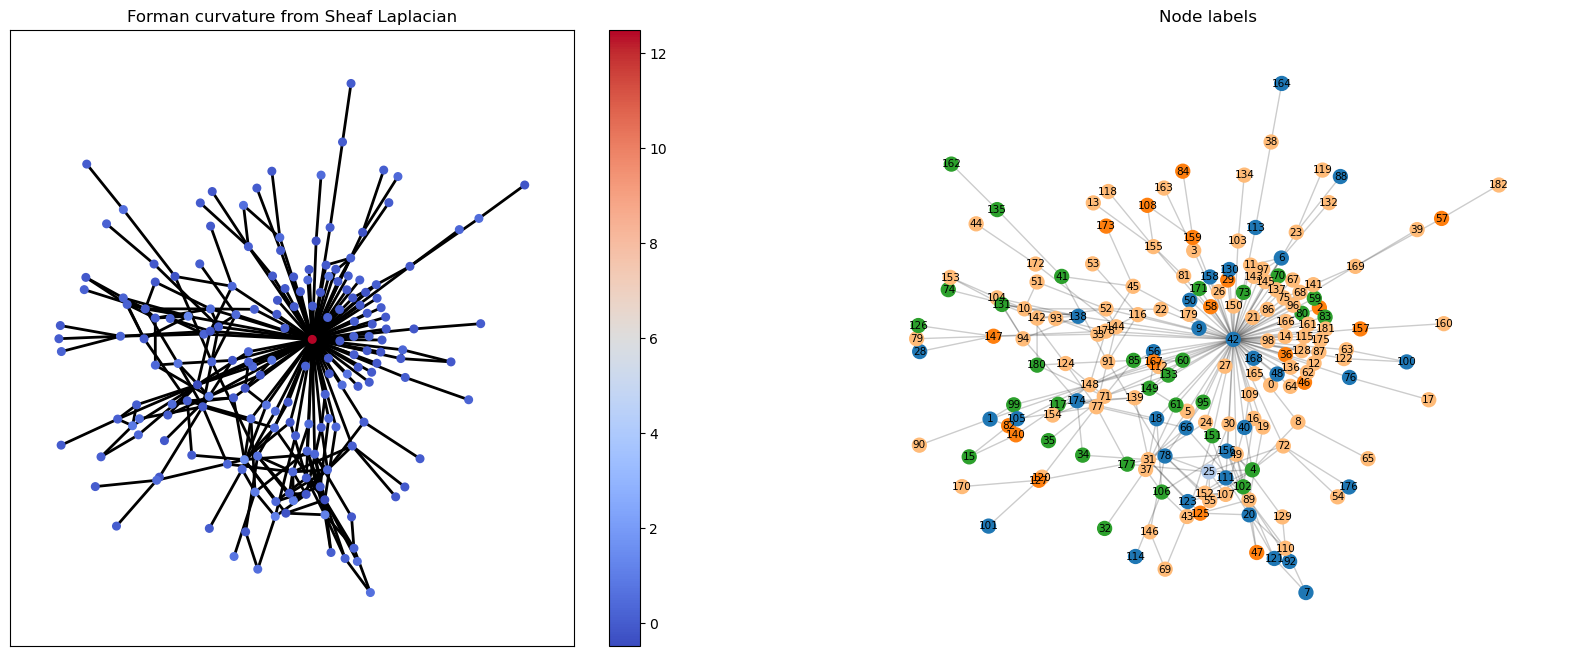

In [59]:
pos = nx.spring_layout(G)
lab = df_node_feature["label"].values
display(lab)

# Plot graph nodes colored by `lab` (handles one-hot or integer labels). Uses existing `G` and `pos` if present.
f,ax = plt.subplots(1,2,figsize=(20,8))
cmap = plt.cm.coolwarm

norm0 = plt.Normalize(vmin=f0.min(), vmax=f0.max())
nx.draw_networkx_nodes(G, ax=ax[0], node_color=cmap(norm0(f0)), pos = pos, node_size=30)
nx.draw_networkx_edges(G,ax =ax[0],pos = pos, width=2)
sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
ax[0].set_title("Forman curvature from Sheaf Laplacian")
plt.colorbar(sm0, ax=ax[0])

if isinstance(labels, np.ndarray) and labels.ndim == 2:
    labels = labels.argmax(axis=1)

labels = lab
unique = np.unique(labels)

cmap_classes = plt.get_cmap('tab20')
label_to_idx = {val: i for i, val in enumerate(unique)}
node_colors = [cmap_classes(label_to_idx[int(labels[n]) % 20]) for n in sorted(G.nodes())]

pos_use = pos if 'pos' in globals() and isinstance(pos, dict) else nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, ax=ax[1], node_color=node_colors, node_size=100, pos=pos_use)
nx.draw_networkx_edges(G, ax=ax[1], pos=pos_use, alpha=0.2)
nx.draw_networkx_labels(G, ax=ax[1], pos=pos_use, font_size=7.5)
ax[1].set_title("Node labels")
plt.axis('off')

plt.show()

array([-1.49416415e+00, -1.11787870e+00, -2.86603867e-01, -3.42313395e-01,
       -1.05216953e+00, -3.39965263e+01, -4.05963626e+01, -7.00184370e-02,
       -8.94013870e-01, -1.42088998e+00, -1.57619629e+00, -1.17599083e+00,
       -1.57850882e+00, -9.77437582e-01, -1.59632980e+00, -7.96259464e-02,
       -1.57049122e+00, -6.98762789e-01, -3.64023043e+01, -4.09485658e-01,
       -6.82983244e-01, -8.33026358e-01, -4.86381172e-01,  2.17212181e-01,
       -4.19756015e+01,  2.39113819e-01, -1.33289637e+01, -4.56258345e-01,
       -1.93126212e+00, -1.60381994e-01, -3.81779375e-01, -1.44346050e+00,
       -1.09259177e+00, -1.34644182e+00, -6.97862605e-01, -4.17030394e+00,
       -3.66464209e+01, -3.40932243e-01, -1.93094700e+01, -1.73983338e-01,
        4.07751304e-01, -8.87796301e+00, -1.32919960e-01,  4.55738246e-01,
       -2.42773231e+00, -6.82322044e+00, -9.85925149e-01, -5.82301409e-01,
       -5.59749983e+00, -1.78858859e+00, -1.93196396e+00, -9.86061711e-01,
       -3.95545275e+00, -

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

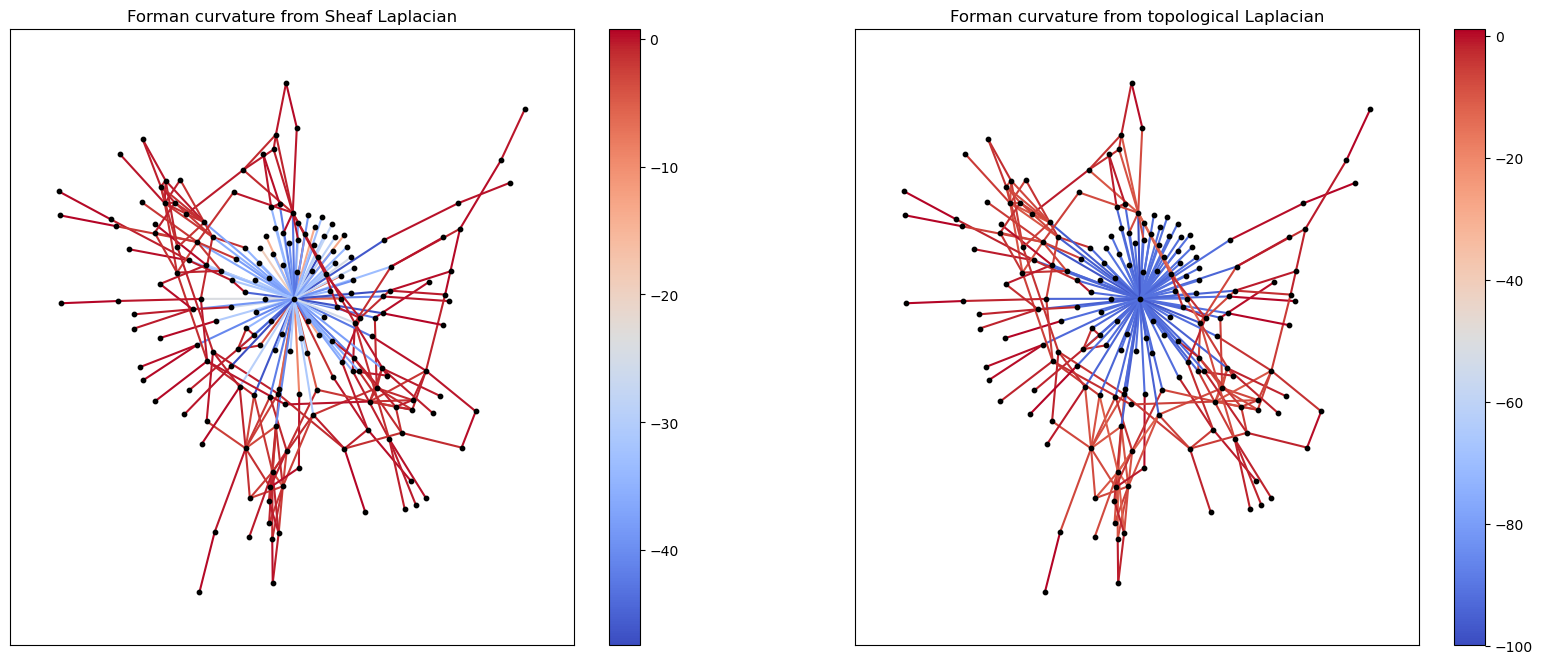

In [60]:
G = nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(edge_list)
f1 = np.diag(F1)
display(f1)

# pos = nx.spring_layout(G)
# f,ax = plt.subplots(1,1,figsize=(10,7))
# nx.draw_networkx_nodes(G, ax=ax, node_color='lightblue', pos = pos, node_size=30)
# #nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
# cmap = plt.cm.coolwarm
# norm1 = plt.Normalize(vmin=f1.min(), vmax=f1.max())
# nx.draw_networkx_edges(G,ax =ax, edge_color = cmap(norm1(f1)),pos = pos, width=2)
# sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1)
# plt.colorbar(sm1, ax=ax, label='Forman curvature')

B_top = nx.incidence_matrix(G).todense()
L0_top = B_top @ B_top.T
L1_top = B_top.T @ B_top
B0_top, F0_top = fbc(L0_top)
B1_top, F1_top = fbc(L1_top)
f0_top = np.diag(F0_top)
f1_top = np.diag(F1_top)
display(f0_top)
display(B_top)

# pos = nx.spring_layout(G)
# f,ax = plt.subplots(1,1,figsize=(10,7))
# nx.draw_networkx_nodes(G, ax=ax, node_color='lightblue', pos = pos, node_size=30)
# #nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
# cmap = plt.cm.coolwarm
# norm1_top = plt.Normalize(vmin=f1.min(), vmax=f1.max())
# nx.draw_networkx_edges(G,ax =ax, edge_color = cmap(norm1_top(f1_top)),pos = pos, width=2)
# sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1_top)
# plt.colorbar(sm1, ax=ax, label='Forman curvature topological ')
# f.show()

pos = nx.spring_layout(G)
f,ax = plt.subplots(1,2,figsize=(20,8))
cmap = plt.cm.coolwarm

nx.draw_networkx_nodes(G, ax=ax[0], node_color='k', pos = pos, node_size=10)
nx.draw_networkx_nodes(G, ax=ax[1], node_color='k', pos = pos, node_size=10)

norm1 = plt.Normalize(vmin=f1.min(), vmax=f1.max())
norm1_top = plt.Normalize(vmin=f1_top.min(), vmax=f1_top.max())

nx.draw_networkx_edges(G,ax =ax[0], edge_color = cmap(norm1(f1)),pos = pos, width=1.5)
nx.draw_networkx_edges(G,ax =ax[1], edge_color = cmap(norm1_top(f1_top)),pos = pos, width=1.5)

sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1)
plt.colorbar(sm1, ax=ax[0])
sm1_top = plt.cm.ScalarMappable(cmap=cmap, norm=norm1_top)
plt.colorbar(sm1_top, ax=ax[1])

ax[0].set_title("Forman curvature from Sheaf Laplacian")
ax[1].set_title("Forman curvature from topological Laplacian")
plt.show()

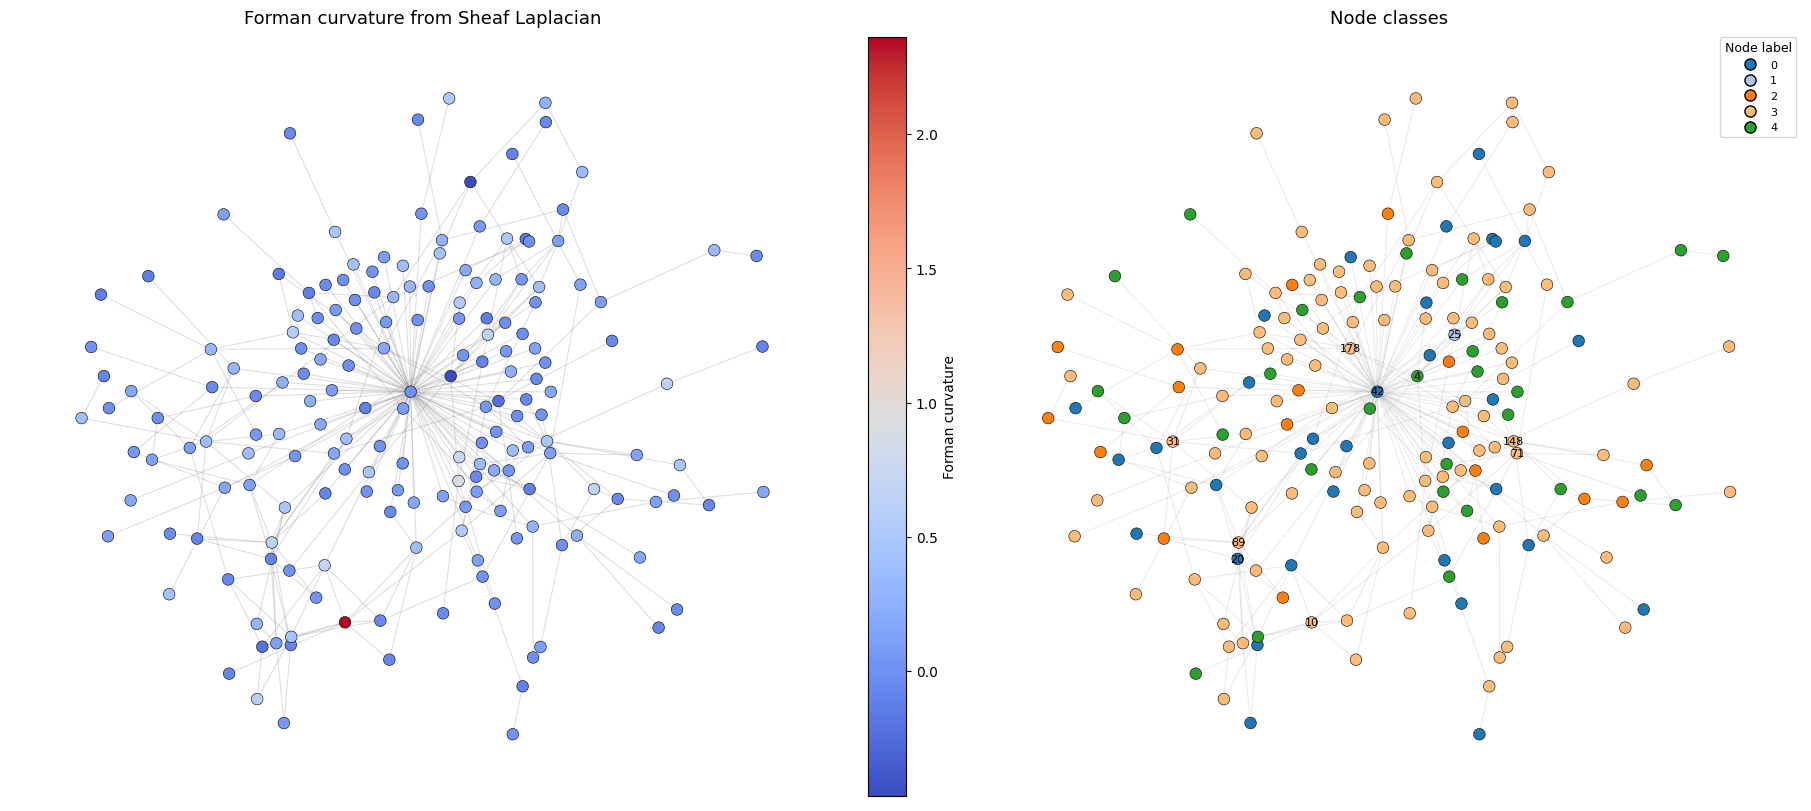

In [277]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

# Stable layout
pos = nx.spring_layout(G, seed=42, k=0.25)

labels = df_node_feature["label"].values
if isinstance(labels, np.ndarray) and labels.ndim == 2:
    labels = labels.argmax(axis=1)

# Make sure node ordering matches graph nodes
nodes_sorted = sorted(G.nodes())
labels_sorted = np.array([labels[n] for n in nodes_sorted])
f0_sorted = np.array([f0[n] for n in nodes_sorted])

fig, ax = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

# ------------------------
# Panel 1: curvature plot
# ------------------------
cmap_curv = plt.cm.coolwarm
norm_curv = Normalize(vmin=f0_sorted.min(), vmax=f0_sorted.max())

nx.draw_networkx_edges(
    G,
    pos=pos,
    ax=ax[0],
    width=0.8,
    alpha=0.25,
    edge_color="gray"
)

nx.draw_networkx_nodes(
    G,
    pos=pos,
    ax=ax[0],
    node_color=f0_sorted,
    cmap=cmap_curv,
    vmin=f0_sorted.min(),
    vmax=f0_sorted.max(),
    node_size=70,
    linewidths=0.4,
    edgecolors="black"
)

sm = plt.cm.ScalarMappable(cmap=cmap_curv, norm=norm_curv)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax[0], fraction=0.046, pad=0.04)
cbar.set_label("Forman curvature")

ax[0].set_title("Forman curvature from Sheaf Laplacian", fontsize=13)
ax[0].set_axis_off()

# ------------------------
# Panel 2: class labels
# ------------------------
unique_labels = np.unique(labels_sorted)
cmap_cls = plt.get_cmap("tab20")
label_to_idx = {val: i for i, val in enumerate(unique_labels)}

node_colors = [cmap_cls(label_to_idx[val] % 20) for val in labels_sorted]

nx.draw_networkx_edges(
    G,
    pos=pos,
    ax=ax[1],
    width=0.8,
    alpha=0.15,
    edge_color="gray"
)

nx.draw_networkx_nodes(
    G,
    pos=pos,
    ax=ax[1],
    node_color=node_colors,
    node_size=70,
    linewidths=0.4,
    edgecolors="black"
)

# Only label a few nodes if desired, not all of them
# example: highest-degree nodes
deg = dict(G.degree())
top_nodes = sorted(deg, key=deg.get, reverse=True)[:10]
label_dict = {n: str(n) for n in top_nodes}

nx.draw_networkx_labels(
    G,
    pos=pos,
    labels=label_dict,
    ax=ax[1],
    font_size=8
)

legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cmap_cls(label_to_idx[val] % 20),
           markeredgecolor='black',
           markersize=8,
           label=str(val))
    for val in unique_labels
]

ax[1].legend(
    handles=legend_handles,
    title="Node label",
    loc="upper right",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)

ax[1].set_title("Node classes", fontsize=13)
ax[1].set_axis_off()

plt.show()

## 5. 2-layer Sheaf

In [278]:
maps = torch.load("/Users/luigifracassetti/projects/neural-sheaf-diffusion/results/maps/DiagSheaf_cornell_fold0_seed43_20260317_180409.pt")

print(type(maps))

<class 'torch.Tensor'>
